In [4]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Configurar conexión a la base de datos
load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'dev_survey_insights')
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

In [6]:
# Cargar datos desde raw_survey
query = "SELECT * FROM raw_survey"
df = pd.read_sql(query, engine)
print(f"Datos cargados correctamente. Filas: {len(df)}, Columnas: {len(df.columns)}")

Datos cargados correctamente. Filas: 98855, Columnas: 129


In [7]:
# Análisis inicial
print("Dimensiones del dataset:", df.shape)
print("\nInformación de columnas:")
print(df.info())

Dimensiones del dataset: (98855, 129)

Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98855 entries, 0 to 98854
Columns: 129 entries, Respondent to SurveyEasy
dtypes: float64(41), int64(1), object(87)
memory usage: 97.3+ MB
None


In [8]:
# Porcentaje de valores nulos por columna
null_percentage = df.isnull().mean() * 100
print("\nPorcentaje de valores nulos por columna:")
print(null_percentage[null_percentage > 0])


Porcentaje de valores nulos por columna:
Country             0.416772
Student             3.999798
Employment          3.574933
FormalEducation     4.200091
UndergradMajor     20.048556
                     ...    
Age                34.678064
Dependents         36.678974
MilitaryUS         84.036215
SurveyTooLong      33.295230
SurveyEasy         33.357949
Length: 126, dtype: float64


In [12]:
# Seleccionar columnas relevantes (ejemplo)
relevant_columns = ['Respondent', 'Country', 'Employment', 'FormalEducation', 'DevType', 'YearsCoding', 'Salary', 'ConvertedSalary','Age']
df_relevant = df[relevant_columns]

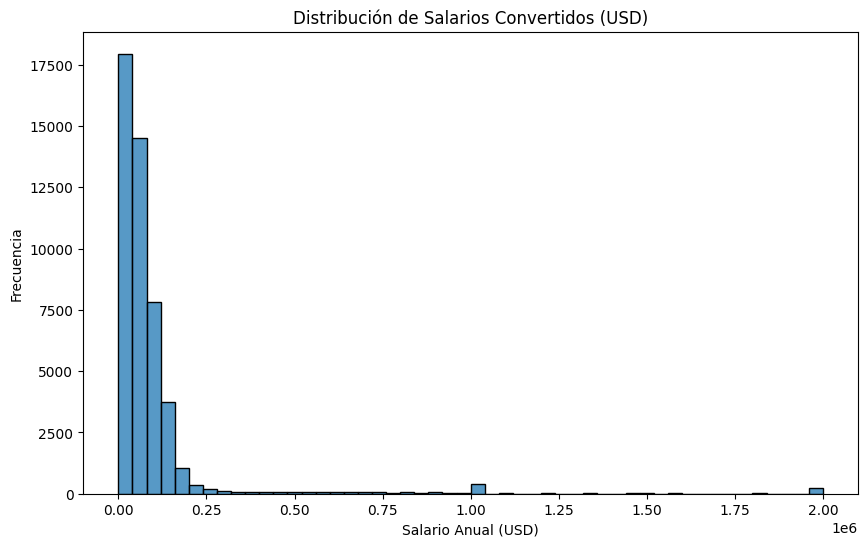

In [13]:
# Visualización: Distribución de ConvertedSalary
plt.figure(figsize=(10, 6))
sns.histplot(df_relevant['ConvertedSalary'].dropna(), bins=50)
plt.title('Distribución de Salarios Convertidos (USD)')
plt.xlabel('Salario Anual (USD)')
plt.ylabel('Frecuencia')
plt.show()

In [14]:
# Análisis de valores nulos en columnas relevantes
print("\nValores nulos en columnas relevantes:")
print(df_relevant.isnull().sum())


Valores nulos en columnas relevantes:
Respondent             0
Country              412
Employment          3534
FormalEducation     4152
DevType             6757
YearsCoding         5020
Salary             48277
ConvertedSalary    51153
Age                34281
dtype: int64
